# 7-Day Model Tuning — Optuna (All 4 Models)

Tunes all 4 models using Optuna, then compares **tuned vs untuned** on the test set.
The better version of each model is saved to `artifacts/models/7_day_models/`.

**Tuning strategy:**
- Objective: minimise **MAE on val set** (test is never touched during tuning)
- 50 trials per model
- Best params → retrain on full `train_df` → evaluate on `test_df`

| Model | Tuned params |
|-------|-------------|
| LightGBM | num_leaves, lr, n_estimators, min_child_samples, feature/bagging_fraction, reg_alpha/lambda |
| XGBoost | n_estimators, lr, max_depth, subsample, colsample_bytree, reg_alpha/lambda, min_child_weight |
| Random Forest | n_estimators, max_depth, min_samples_leaf, max_features |
| Neural Network | hidden layers, lr, alpha (L2), batch_size |

## 1) Imports & Paths

In [1]:
from pathlib import Path
import copy, warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

RANDOM_SEED = 42
N_TRIALS    = 50

ROOT     = Path('..').resolve()
DATA_DIR = ROOT / 'data' / 'processed' / '7_Day_Dataset'
SAVE_DIR = ROOT / 'artifacts' / 'models' / '7_day_models'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print(f'Data dir : {DATA_DIR}')
print(f'Save dir : {SAVE_DIR}')
print(f'Trials   : {N_TRIALS} per model')

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data dir : C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\data\processed\7_Day_Dataset
Save dir : C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\artifacts\models\7_day_models
Trials   : 50 per model


## 2) Load Data

In [2]:
train_df = pd.read_csv(DATA_DIR / 'train.csv', parse_dates=['date'])
val_df   = pd.read_csv(DATA_DIR / 'val.csv',   parse_dates=['date'])
test_df  = pd.read_csv(DATA_DIR / 'test.csv',  parse_dates=['date'])

TARGET   = 'aggregated_sales_7'
DROP     = [TARGET, 'item_id', 'date']
FEATURES = [c for c in train_df.columns if c not in DROP]

X_train = train_df[FEATURES];  y_train = train_df[TARGET]
X_val   = val_df[FEATURES];    y_val   = val_df[TARGET]
X_test  = test_df[FEATURES];   y_test  = test_df[TARGET]

print(f'Train : {len(train_df):,} rows')
print(f'Val   : {len(val_df):,} rows')
print(f'Test  : {len(test_df):,} rows')
print(f'Features ({len(FEATURES)}): {FEATURES}')

Train : 274,467 rows
Val   : 58,917 rows
Test  : 60,354 rows
Features (31): ['is_month_end', 'aggregated_sell_price', 'snap_ca', 'event_christmas_7', 'event_easter_7', 'event_eid_al_fitr_7', 'event_eid_al_adha_7', 'event_fathers_day_7', 'event_halloween_7', 'event_mothers_day_7', 'event_newyear_7', 'event_orthodox_christmas_7', 'event_orthodox_easter_7', 'event_ramadan_starts_7', 'event_thanksgiving_7', 'event_valentines_day_7', 'event_superbowl_7', 'event_independence_day_7', 'event_memorial_day_7', 'event_labor_day_7', 'event_mlk_day_7', 'event_presidents_day_7', 'event_columbus_day_7', 'event_veterans_day_7', 'event_st_patricks_day_7', 'event_cinco_de_mayo_7', 'event_chanukah_7', 'event_lent_start_7', 'event_lent_week2_7', 'event_pesach_end_7', 'event_purim_end_7']


## 3) Helpers

In [3]:
def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)))

def compute_metrics(y_true, y_pred, label=''):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        'model':  label,
        'MAE':   round(float(mean_absolute_error(y_true, y_pred)), 4),
        'RMSE':  round(float(np.sqrt(mean_squared_error(y_true, y_pred))), 4),
        'SMAPE': round(smape(y_true, y_pred), 4),
        'BIAS':  round(float(np.mean(y_pred - y_true)), 4),
    }

def make_pipeline(model):
    return Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale',  StandardScaler()),
        ('model',  model),
    ])

print('Helpers ready.')

Helpers ready.


## 4) Train Untuned Baselines (same defaults as notebook 22)

In [4]:
UNTUNED = {
    'LightGBM': make_pipeline(LGBMRegressor(
        n_estimators=500, learning_rate=0.05, num_leaves=31,
        subsample=0.9, colsample_bytree=0.9,
        random_state=RANDOM_SEED, verbose=-1,
    )),
    'XGBoost': make_pipeline(XGBRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=6,
        subsample=0.85, colsample_bytree=0.85,
        reg_alpha=0.1, reg_lambda=1.0,
        objective='reg:squarederror', tree_method='hist',
        random_state=RANDOM_SEED, verbosity=0,
    )),
    'Random Forest': make_pipeline(RandomForestRegressor(
        n_estimators=200, min_samples_leaf=5,
        n_jobs=-1, random_state=RANDOM_SEED,
    )),
    'Neural Network': make_pipeline(MLPRegressor(
        hidden_layer_sizes=(128, 64), activation='relu', solver='adam',
        learning_rate_init=0.001, max_iter=300,
        early_stopping=True, validation_fraction=0.1,
        random_state=RANDOM_SEED,
    )),
}

untuned_trained = {}
untuned_rows    = []
for name, pipe in UNTUNED.items():
    print(f'Training untuned {name}...')
    p = copy.deepcopy(pipe)
    p.fit(X_train, y_train)
    untuned_trained[name] = p
    m = compute_metrics(y_test.values, p.predict(X_test), label=f'{name} (untuned)')
    untuned_rows.append(m)
    print(f'  Test MAE={m["MAE"]:.4f}  SMAPE={m["SMAPE"]:.2f}%')

print('\nAll untuned baselines trained.')

Training untuned LightGBM...


  File "c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.Crea

  Test MAE=12.3819  SMAPE=96.39%
Training untuned XGBoost...
  Test MAE=12.4175  SMAPE=95.75%
Training untuned Random Forest...
  Test MAE=12.5989  SMAPE=99.40%
Training untuned Neural Network...
  Test MAE=12.3686  SMAPE=95.14%

All untuned baselines trained.


## 5) Optuna Tuning — LightGBM

Objective: minimise **val MAE**. Test is never seen during tuning.

In [5]:
def lgbm_objective(trial):
    params = dict(
        num_leaves        = trial.suggest_int('num_leaves', 20, 150),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        n_estimators      = trial.suggest_int('n_estimators', 100, 1000),
        min_child_samples = trial.suggest_int('min_child_samples', 10, 100),
        feature_fraction  = trial.suggest_float('feature_fraction', 0.5, 1.0),
        bagging_fraction  = trial.suggest_float('bagging_fraction', 0.5, 1.0),
        bagging_freq      = 1,
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        random_state      = RANDOM_SEED,
        verbose           = -1,
    )
    pipe = make_pipeline(LGBMRegressor(**params))
    pipe.fit(X_train, y_train)
    return mean_absolute_error(y_val, pipe.predict(X_val))

print(f'Tuning LightGBM ({N_TRIALS} trials)...')
study_lgbm = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
study_lgbm.optimize(lgbm_objective, n_trials=N_TRIALS, show_progress_bar=True)
print(f'Best val MAE: {study_lgbm.best_value:.4f}')
print(f'Best params : {study_lgbm.best_params}')

Tuning LightGBM (50 trials)...


Best trial: 45. Best value: 12.7616: 100%|██████████| 50/50 [05:50<00:00,  7.01s/it]

Best val MAE: 12.7616
Best params : {'num_leaves': 95, 'learning_rate': 0.019356585415668936, 'n_estimators': 151, 'min_child_samples': 15, 'feature_fraction': 0.5562473987572466, 'bagging_fraction': 0.9799173958538121, 'reg_lambda': 0.004690790600319218, 'reg_alpha': 0.0011364569457596241}


## 6) Optuna Tuning — XGBoost

In [6]:
def xgb_objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 100, 800),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        max_depth         = trial.suggest_int('max_depth', 3, 10),
        subsample         = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        min_child_weight  = trial.suggest_int('min_child_weight', 1, 10),
        objective         = 'reg:squarederror',
        tree_method       = 'hist',
        random_state      = RANDOM_SEED,
        verbosity         = 0,
    )
    pipe = make_pipeline(XGBRegressor(**params))
    pipe.fit(X_train, y_train)
    return mean_absolute_error(y_val, pipe.predict(X_val))

print(f'Tuning XGBoost ({N_TRIALS} trials)...')
study_xgb = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
study_xgb.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=True)
print(f'Best val MAE: {study_xgb.best_value:.4f}')
print(f'Best params : {study_xgb.best_params}')

Tuning XGBoost (50 trials)...


Best trial: 25. Best value: 12.9466: 100%|██████████| 50/50 [03:34<00:00,  4.29s/it]

Best val MAE: 12.9466
Best params : {'n_estimators': 294, 'learning_rate': 0.040383700461943804, 'max_depth': 4, 'subsample': 0.8620263318449886, 'colsample_bytree': 0.7726547601367543, 'reg_alpha': 0.014894506734655553, 'reg_lambda': 0.22311636515818342, 'min_child_weight': 8}


## 7) Optuna Tuning — Random Forest

In [7]:
def rf_objective(trial):
    params = dict(
        n_estimators    = trial.suggest_int('n_estimators', 100, 500),
        max_depth       = trial.suggest_int('max_depth', 5, 40),
        min_samples_leaf= trial.suggest_int('min_samples_leaf', 1, 20),
        max_features    = trial.suggest_float('max_features', 0.3, 1.0),
        n_jobs          = -1,
        random_state    = RANDOM_SEED,
    )
    pipe = make_pipeline(RandomForestRegressor(**params))
    pipe.fit(X_train, y_train)
    return mean_absolute_error(y_val, pipe.predict(X_val))

print(f'Tuning Random Forest ({N_TRIALS} trials)...')
study_rf = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
study_rf.optimize(rf_objective, n_trials=N_TRIALS, show_progress_bar=True)
print(f'Best val MAE: {study_rf.best_value:.4f}')
print(f'Best params : {study_rf.best_params}')

Tuning Random Forest (50 trials)...


Best trial: 45. Best value: 12.8894: 100%|██████████| 50/50 [08:36<00:00, 10.33s/it]

Best val MAE: 12.8894
Best params : {'n_estimators': 213, 'max_depth': 13, 'min_samples_leaf': 18, 'max_features': 0.6313158220716878}


## 8) Optuna Tuning — Neural Network

In [8]:
# Subsample to 40K rows for tuning only — each trial ~15s instead of ~5 min
# The final model (cell 9) still trains on the full train set
rng      = np.random.default_rng(RANDOM_SEED)
tune_idx = rng.choice(len(X_train), size=40_000, replace=False)
X_tune   = X_train.iloc[tune_idx]
y_tune   = y_train.iloc[tune_idx]

def nn_objective(trial):
    n_layers = trial.suggest_int('n_layers', 1, 3)
    layers   = tuple(trial.suggest_int(f'units_l{i}', 32, 256) for i in range(n_layers))
    params = dict(
        hidden_layer_sizes  = layers,
        activation          = trial.suggest_categorical('activation', ['relu', 'tanh']),
        learning_rate_init  = trial.suggest_float('learning_rate_init', 1e-4, 0.01, log=True),
        alpha               = trial.suggest_float('alpha', 1e-5, 0.1, log=True),
        batch_size          = trial.suggest_categorical('batch_size', [64, 128, 256]),
        max_iter            = 200,
        early_stopping      = True,
        validation_fraction = 0.1,
        solver              = 'adam',
        random_state        = RANDOM_SEED,
    )
    pipe = make_pipeline(MLPRegressor(**params))
    pipe.fit(X_tune, y_tune)
    return mean_absolute_error(y_val, pipe.predict(X_val))

print(f'Tuning Neural Network ({N_TRIALS} trials on 40K subsample)...')
study_nn = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
study_nn.optimize(nn_objective, n_trials=N_TRIALS, show_progress_bar=True)
print(f'Best val MAE: {study_nn.best_value:.4f}')
print(f'Best params : {study_nn.best_params}')

Tuning Neural Network (50 trials on 40K subsample)...


Best trial: 41. Best value: 12.6983: 100%|██████████| 50/50 [55:44<00:00, 66.88s/it] 

Best val MAE: 12.6983
Best params : {'n_layers': 3, 'units_l0': 159, 'units_l1': 67, 'units_l2': 211, 'activation': 'relu', 'learning_rate_init': 0.0017566152589312519, 'alpha': 0.008509480711184682, 'batch_size': 128}


## 9) Train Tuned Models on Full Train Set

In [9]:
# ── LightGBM tuned ────────────────────────────────────────────────────────────
lgbm_tuned = make_pipeline(LGBMRegressor(
    **study_lgbm.best_params, bagging_freq=1,
    random_state=RANDOM_SEED, verbose=-1
))
lgbm_tuned.fit(X_train, y_train)

# ── XGBoost tuned ─────────────────────────────────────────────────────────────
xgb_tuned = make_pipeline(XGBRegressor(
    **study_xgb.best_params,
    objective='reg:squarederror', tree_method='hist',
    random_state=RANDOM_SEED, verbosity=0
))
xgb_tuned.fit(X_train, y_train)

# ── Random Forest tuned ───────────────────────────────────────────────────────
rf_tuned = make_pipeline(RandomForestRegressor(
    **study_rf.best_params, n_jobs=-1, random_state=RANDOM_SEED
))
rf_tuned.fit(X_train, y_train)

# ── Neural Network tuned ──────────────────────────────────────────────────────
nn_best = study_nn.best_params.copy()
n_layers = nn_best.pop('n_layers')
layers   = tuple(nn_best.pop(f'units_l{i}') for i in range(n_layers))
nn_tuned = make_pipeline(MLPRegressor(
    hidden_layer_sizes=layers, max_iter=300,
    early_stopping=True, validation_fraction=0.1,
    solver='adam', random_state=RANDOM_SEED, **nn_best
))
nn_tuned.fit(X_train, y_train)

TUNED = {
    'LightGBM':      lgbm_tuned,
    'XGBoost':       xgb_tuned,
    'Random Forest': rf_tuned,
    'Neural Network':nn_tuned,
}
print('All tuned models trained.')

All tuned models trained.


## 10) Tuned vs Untuned — Test Set Comparison

In [10]:
tuned_rows = []
for name, pipe in TUNED.items():
    m = compute_metrics(y_test.values, pipe.predict(X_test), label=f'{name} (tuned)')
    tuned_rows.append(m)

all_rows = untuned_rows + tuned_rows
results  = pd.DataFrame(all_rows)

# Sort: group by model name then tuned/untuned
results['base'] = results['model'].str.replace(r' \(.*\)', '', regex=True)
results = results.sort_values(['base', 'model']).drop(columns='base').reset_index(drop=True)

print('=== Tuned vs Untuned — Test Set ===')
print(results.to_string(index=False))

=== Tuned vs Untuned — Test Set ===
                   model     MAE    RMSE   SMAPE    BIAS
        LightGBM (tuned) 12.1728 25.8879 94.1228 -0.8339
      LightGBM (untuned) 12.3819 26.2225 96.3851 -1.1077
  Neural Network (tuned) 12.3046 26.0637 94.4539 -0.8268
Neural Network (untuned) 12.3686 25.9942 95.1370 -0.6011
   Random Forest (tuned) 12.3275 26.1262 94.6915 -0.8619
 Random Forest (untuned) 12.5989 26.4929 99.3981 -1.2273
         XGBoost (tuned) 12.3161 26.0427 94.2136 -0.5973
       XGBoost (untuned) 12.4175 26.2267 95.7451 -0.7828


## 11) Side-by-Side Bar Chart — MAE Tuned vs Untuned

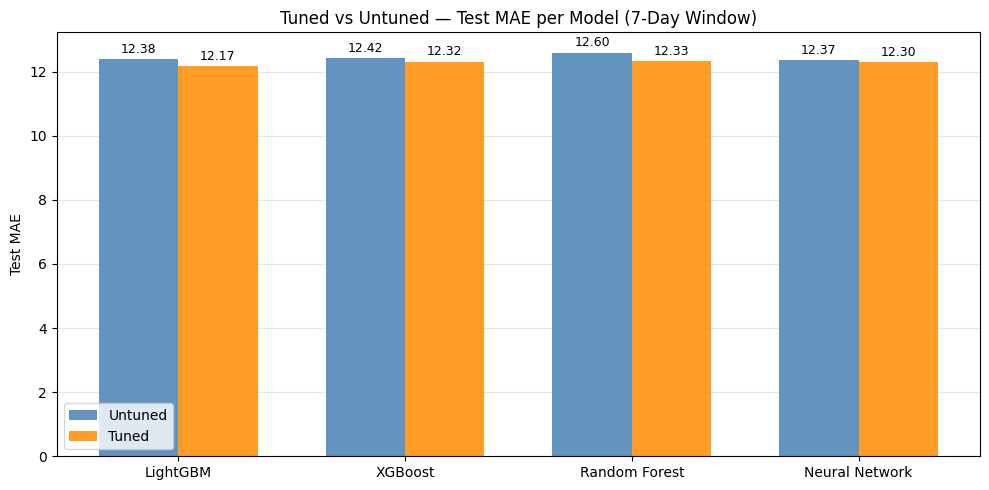

In [11]:
model_names = ['LightGBM', 'XGBoost', 'Random Forest', 'Neural Network']
untuned_mae = [next(r['MAE'] for r in untuned_rows if r['model'].startswith(n)) for n in model_names]
tuned_mae   = [next(r['MAE'] for r in tuned_rows   if r['model'].startswith(n)) for n in model_names]

x     = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, untuned_mae, width, label='Untuned', color='steelblue',   alpha=0.85)
bars2 = ax.bar(x + width/2, tuned_mae,   width, label='Tuned',   color='darkorange', alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylabel('Test MAE')
ax.set_title('Tuned vs Untuned — Test MAE per Model (7-Day Window)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## 12) Save All 4 Tuned Models

In [12]:
SAVE_DIR = ROOT / 'artifacts' / 'models' / '7_day_models'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(lgbm_tuned, SAVE_DIR / 'lightgbm_7d_tuned.joblib')
joblib.dump(xgb_tuned,  SAVE_DIR / 'xgboost_7d_tuned.joblib')
joblib.dump(rf_tuned,   SAVE_DIR / 'random_forest_7d_tuned.joblib')
joblib.dump(nn_tuned,   SAVE_DIR / 'neural_network_7d_tuned.joblib')

print(f'Saved to {SAVE_DIR}')
for f in sorted(SAVE_DIR.glob('*.joblib')):
    size_mb = f.stat().st_size / 1024 / 1024
    print(f'  {f.name:45s} {size_mb:.1f} MB')

Saved to C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\artifacts\models\7_day_models
  lightgbm_7d_tuned.joblib                      0.9 MB
  neural_network_7d_tuned.joblib                0.7 MB
  random_forest_7d_tuned.joblib                 18.0 MB
  xgboost_7d_tuned.joblib                       0.4 MB
